Постановка задачи:

Есть обыкновенное дифференциальное уравнение первого порядка, разрешенное относительно производной $\frac{dy}{dt} = \lambda y$, где $\lambda = -1$.

Решением этого уравнения будет считаться функция (функции) $y = y(t)$, обращающая приведенное выше выражение в тождество на отрезке $[a,b]$ 

### Решим его $методом \ Эйлера$ $(метод \ степенных \ рядов)$



In [2]:
"""
Для постановки задачи Коши нам необходимо какое-то начальное значение, сделаем его выбор произвольным, но
для определенности зафиксируем конкретное.
"""

y0 = 15
Lambda = -1


In [3]:
"""
Зададим произвольный отрезок [a, b], однако, все же, зафиксируем границы (для определенности)
"""

a = -100
b = 10

In [4]:
"""
Создадим функцию разбиения промежутка [a,b] на N интервалов
"""

def grid(a, b, N):
    h = (b - a)/N
    grid = [a + i*h for i in range(N + 1)]
    return grid, h


In [5]:
"""
Напишем функцию нахождения значения y_{j+1} приближенного решения в точке t_{j+1} = t_{j} + h
"""

def power_series_method_1(t, y, h, f): #локальная погрешность O(h^2)
    return y + h*f(t, y)

In [6]:
"""
Для двух следующих функций потребуется так же написать функции производной
"""

def f(t, y):
    return Lambda * y

def f_t(t, y):
    return 0.0

def f_y(t, y):
    return Lambda

def f_tt(t, y):
    return 0.0

def f_ty(t, y):
    return 0.0

def f_yy(t, y):
    return 0.0



In [7]:
"""
Напишем теперь функции нахождения значения y_{j+1} с большими порядками точности
"""


def power_series_method_2(t, y, h, f): #локальная погрешность O(h^3)
    F = f(t, y)
    y2 = f_t(t, y) + F * f_y(t, y)         
    return y + h * F + (h**2) / 2.0 * y2


# def power_series_method_3(t, y, h, f): #локальная погрешность O(h^4)
#     F = f(t, y)
#     ft = f_t(t, y)
#     fy = f_y(t, y)

#     y2 = ft + F * fy


#     y3 = (
#         f_tt(t, y)
#         + 2.0 * F * f_ty(t, y)
#         + ft * fy
#         + F * (fy**2)
#         + (F**2) * f_yy(t, y)
#     )

#     return y + h * F + (h**2) / 2.0 * y2 + (h**3) / 6.0 * y3

def power_series_method_3(t, y, h, f):
    z = h * Lambda
    return y * (1 + z + z**2 / 2 + z**3 / 6)


In [8]:
"""
Импортируем библиотеку для отрисовки графиков, а также Numpy
"""

import matplotlib.pyplot as plt
import numpy as np

Ну и найдем непосредственно аналитическое решение нашего дифференциального уравнения

$$\frac{dy}{dt} = \lambda y \Longrightarrow \frac{dy}{y} = \lambda dt \Longrightarrow \int_{y(t_0)}^{y(t)} 
\frac{dy}{y} = \int_{t_0}^{t} \lambda dx \Longrightarrow ln|y(t)| \mid_{y(t_0)}^{y(t)} = $$
$$ = \lambda (t - t_0) \Longrightarrow 
ln|y(t)| - ln|y(t_0)| = \lambda t - \lambda t_0 \Longrightarrow ln|y| = $$
$$ = \lambda t - C \Longrightarrow |y| = e^{\lambda t + C}
= e^C e^{\lambda t} = C e^{\lambda t} \Longrightarrow y = C e^{\lambda t}$$
$$C \in \mathbb{R}$$

Таким образом $C = \frac{y}{e^{\lambda t}}$

In [9]:
"""
Напишем функцию аналитического решения, учитывая нашу начальную задачу
"""

# def analytic_solution(y0, Lambda, t0, t):
#     C = y0 * np.exp(-Lambda * t0)
#     return C * np.exp(Lambda * t)

def analytic_solution(C, Lambda, t0, t):
    return C * np.exp(Lambda * (t - t0))

In [10]:
"""
Зададим теперь сетку и пустой массив для отрисовки значений
"""
N = 10000

values_1 = [y0]
values_2 = [y0]
values_3 = [y0]
values_analytic = [y0]

domain, h = grid(a, b, N)

f = lambda t, y: Lambda * y

for t in range(1, len(domain)):
    values_1.append(power_series_method_1(domain[t-1], values_1[t-1], h, f))
    values_2.append(power_series_method_2(domain[t-1], values_2[t-1], h, f))
    values_3.append(power_series_method_3(domain[t-1], values_3[t-1], h, f))
    values_analytic.append(analytic_solution(values_analytic[0], Lambda, domain[0], domain[t]))

print(domain)

print(values_1)
print(values_2)
print(values_3)
print(values_analytic)



[-100.0, -99.989, -99.978, -99.967, -99.956, -99.945, -99.934, -99.923, -99.912, -99.901, -99.89, -99.879, -99.868, -99.857, -99.846, -99.835, -99.824, -99.813, -99.802, -99.791, -99.78, -99.769, -99.758, -99.747, -99.736, -99.725, -99.714, -99.703, -99.692, -99.681, -99.67, -99.659, -99.648, -99.637, -99.626, -99.615, -99.604, -99.593, -99.582, -99.571, -99.56, -99.549, -99.538, -99.527, -99.516, -99.505, -99.494, -99.483, -99.472, -99.461, -99.45, -99.439, -99.428, -99.417, -99.406, -99.395, -99.384, -99.373, -99.362, -99.351, -99.34, -99.329, -99.318, -99.307, -99.296, -99.285, -99.274, -99.263, -99.252, -99.241, -99.23, -99.219, -99.208, -99.197, -99.186, -99.175, -99.164, -99.153, -99.142, -99.131, -99.12, -99.109, -99.098, -99.087, -99.076, -99.065, -99.054, -99.043, -99.032, -99.021, -99.01, -98.999, -98.988, -98.977, -98.966, -98.955, -98.944, -98.933, -98.922, -98.911, -98.9, -98.889, -98.878, -98.867, -98.856, -98.845, -98.834, -98.823, -98.812, -98.801, -98.79, -98.779, -98.

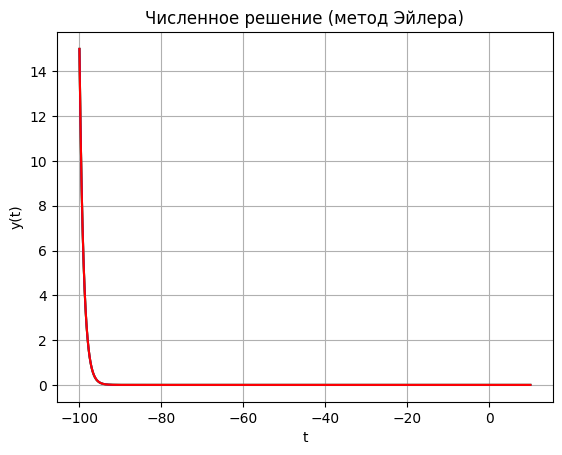

In [11]:
plt.figure()
plt.plot(domain, values_1, color = 'green')
plt.plot(domain, values_2, color = 'yellow')
plt.plot(domain, values_3, color = 'blue')
plt.plot(domain, values_analytic, color = 'red')
plt.xlabel("t")
plt.ylabel("y(t)")
plt.title("Численное решение (метод Эйлера)")
plt.grid(True)
plt.show()

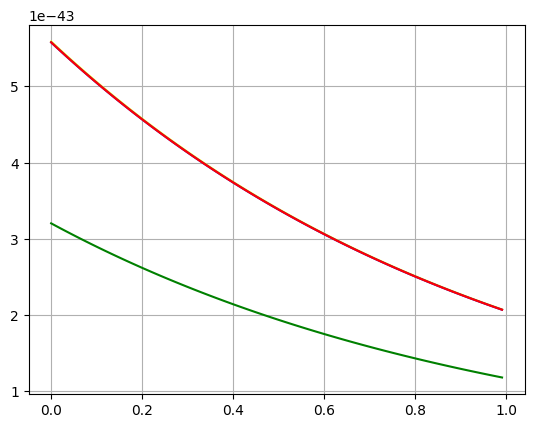

In [12]:
"""
Рассмотрим конкретный промежуток, чтобы было лучше видно графики
"""

mask = [0 <= t <= 1 for t in domain]

domain_zoom = [t for t, m in zip(domain, mask) if m]
v1_zoom = [v for v, m in zip(values_1, mask) if m]
v2_zoom = [v for v, m in zip(values_2, mask) if m]
v3_zoom = [v for v, m in zip(values_3, mask) if m]
v4_zoom = [v for v, m in zip(values_analytic, mask) if m]

plt.figure()
plt.plot(domain_zoom, v1_zoom, color = 'green')
plt.plot(domain_zoom, v2_zoom, color = 'yellow')
plt.plot(domain_zoom, v3_zoom, color = 'blue')
plt.plot(domain_zoom, v4_zoom, color = 'red')
plt.grid(True)
plt.show()


Ну то есть в целом видно, что с повышением порядка у нас приближенное решение практически совпадает с аналитическим

Сделаем теперь таблицу со столбцами $h$ - размер сетки, $\epsilon$ - погрешность, $p$ - порядок.

Вспомним определение **порядка**:  
Говорим, что приближенная формула или приближенный численный метод имеют $p$-й порядок точности (порядок аппроксимации), если на равномерной сетке с шагом $h$ их погрешность является величиной $e(h) = O(h^p)$, т.е. не превосходит $Ch^p$   
(т.е. $e(h) \approx Ch^p$), где $C$ - константа, не зависимая от $h$.

Соответственно, в случае, если $h_1, h_2$ - такие, что шаг $h_2$ в два раза меньше $h_1$ $\Longrightarrow$ $e_1 = Ch_1^p, e_2 = Ch_2^p$, тогда $\frac{e_1}{e_2} = (\frac{h_1}{h_2})^p \Longrightarrow$  
$\Longrightarrow p = \frac{\log_2{\frac{e_1}{e_2}}}{\log_2{\frac{h_1}{h_2}}} = \frac{\log_2{\frac{e_1}{e_2}}}{\log_2{2}} = \frac{\log_2{\frac{e_1}{e_2}}}{1} \Longrightarrow p = \log_2{\frac{e_1}{e_2}}$

In [13]:
"""
Зададим функцию вычисления погрешности
"""
 #подаем на вход массивы значений - аналитическое и численное, максимальный элемент разницы - и есть погрешность
def inaccuracy(analytic_value, approx_value):
    mx = 0
    for i in range(len(analytic_value)):
        mx = max(mx, abs(analytic_value[i] - approx_value[i]))
    return mx

"""
Зададим функцию определения порядка
"""

def order(approx1, approx2, analytic1, analytic2):
    e1 = (inaccuracy(approx1, analytic1))
    e2 = (inaccuracy(approx2, analytic2))
    if e1 == 0 or e2 == 0:
        return np.nan
    return np.log2(e1 / e2)

In [14]:
import pandas as pd

In [15]:
rows = 10
cols = 10

table = [[0 for _ in range(cols)] for _ in range(rows)]


N = [2**i for i in range(1, 17)]

errors_1, errors_2, errors_3 = [], [], []
H = []

for n in N:
    domain, h = grid(a,b,n)

    values_1, values_2, values_3 = [y0], [y0], [y0]
    values_analytic = [analytic_solution(y0, Lambda, domain[0], domain[0])]

    for t in range(1, len(domain)):
        values_1.append(power_series_method_1(domain[t-1], values_1[t-1], h, f))
        values_2.append(power_series_method_2(domain[t-1], values_2[t-1], h, f))
        values_3.append(power_series_method_3(domain[t-1], values_3[t-1], h, f))
        values_analytic.append(analytic_solution(y0, Lambda, domain[0], domain[t]))
    
    H.append(h)
    errors_1.append(inaccuracy(values_analytic, values_1))
    errors_2.append(inaccuracy(values_analytic, values_2))
    errors_3.append(inaccuracy(values_analytic, values_3))

p1 = [np.nan] + [np.log2(errors_1[i-1] / errors_1[i]) for i in range(1, len(errors_1))]
p2 = [np.nan] + [np.log2(errors_2[i-1] / errors_2[i]) for i in range(1, len(errors_2))]
p3 = [np.nan] + [np.log2(errors_3[i-1] / errors_3[i]) for i in range(1, len(errors_3))]

df = pd.DataFrame({
    "N": N,
    "h": H,
    "eps_1": errors_1,
    "eps_2": errors_2,
    "eps_3": errors_3,
    "p_1": p1,
    "p_2": p2,
    "p_3": p3
})

display(df)


,N,h,eps_1,eps_2,eps_3,p_1,p_2,p_3
0,2,55.000000,4.374000e+04,3.190833e+07,1.035222e+10,NaN,NaN,NaN
1,4,27.500000,7.397326e+06,2.293033e+11,1.411420e+15,-7.401907,-12.811036,-17.056848
2,8,13.750000,1.047545e+10,3.001382e+16,3.494340e+21,-10.467721,-16.998010,-21.239441
3,16,6.875000,3.021462e+13,1.466637e+21,1.425116e+26,-11.494019,-15.576526,-15.315699
4,32,3.437500,3.616756e+13,2.947475e+18,5.818368e+17,-0.259449,8.958817,27.867817
5,64,1.718750,1.347060e+01,8.685160e+00,4.008245e+00,41.288019,58.235633,57.010421
6,128,0.859375,4.242025e+00,1.296916e+00,2.897598e-01,1.666989,2.743468,3.790041
7,256,0.429688,1.472554e+00,2.347418e-01,2.547973e-02,1.526432,2.465938,3.507436
8,512,0.214844,6.508645e-01,4.997921e-02,2.701658e-03,1.177892,2.231675,3.237433
9,1024,0.107422,3.105324e-01,1.150955e-02,3.104538e-04,1.067613,2.118497,3.121395


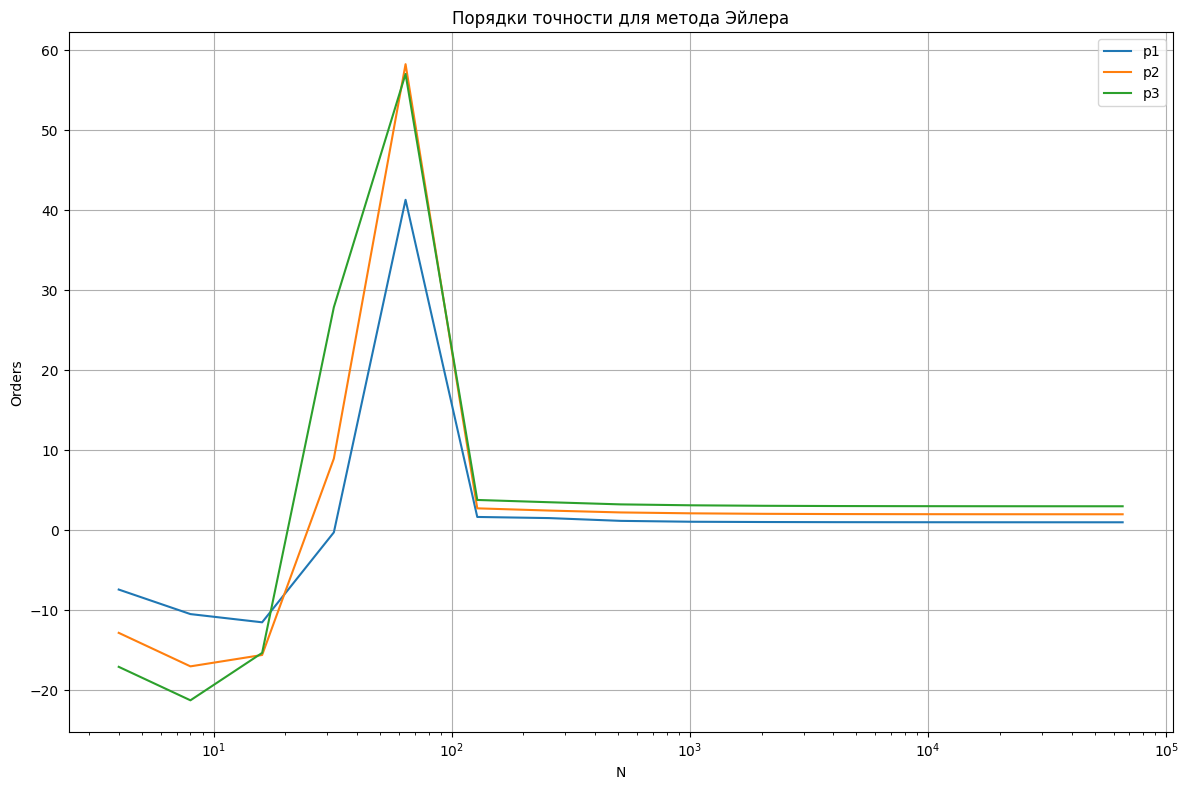

In [16]:
"""
Построим график изменения порядка
"""

plt.figure(figsize=(12,8))
plt.semilogx(N, p1, label="p1")
plt.semilogx(N, p2, label="p2")
plt.semilogx(N, p3, label="p3")
plt.title("Порядки точности для метода Эйлера")
plt.xlabel("N")
plt.ylabel("Orders")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

Решим теперь ту же самую задачу, но с помощью **неявного метода Эйлера**.

### Неявный метод Эйлера.

В неявном методе Эйлера мы используем значение $y_{i+1}$, которое стоит по обе стороны уравнения, поэтому метод и **неявный**.   
$$y_{i+1} = y_i + hf(t_{i+1}, y_{i+1})$$
Наше уравнение: $y' = \lambda y$:  
$$f(t,y) = \lambda y \Longrightarrow y_{i+1} = y_i + h \lambda y_{i+1} \Longrightarrow$$
$$\Longrightarrow y_{i+1}(1-h \lambda) = y_i \Longrightarrow y_{i+1} = \frac{y_i}{1 - h \lambda}$$

In [17]:
def implicit_method(t, y, h, f):
    return y / (1 - h * Lambda)

In [18]:
errors_imp = []

for n in N:
    domain, h = grid(a, b, n)

    values_imp = [y0]
    values_analytic = [analytic_solution(y0, Lambda, domain[0], domain[0])]

    for t in range(1, len(domain)):
        values_imp.append(implicit_method(domain[t-1], values_imp[t-1], h, f))
        values_analytic.append(analytic_solution(y0, Lambda, domain[0], domain[t]))

    errors_imp.append(inaccuracy(values_imp, values_analytic))

p_imp = [np.nan] + [np.log2(errors_imp[i-1] / errors_imp[i]) for i in range(1, len(errors_imp))]

df_imp = pd.DataFrame({
    "N": N,
    "h": H,
    "eps_imp": errors_imp,
    "p_imp": p_imp
})

display(df_imp)

,N,h,eps_imp,p_imp
0,2,55.000000,0.267857,NaN
1,4,27.500000,0.526316,-0.974465
2,8,13.750000,1.016933,-0.950224
3,16,6.875000,1.889262,-0.893598
4,32,3.437500,2.898107,-0.617288
5,64,1.718750,2.827890,0.035385
6,128,0.859375,1.715827,0.720821
7,256,0.429688,1.000026,0.778867
8,512,0.214844,0.545306,0.874898
9,1024,0.107422,0.283581,0.943305


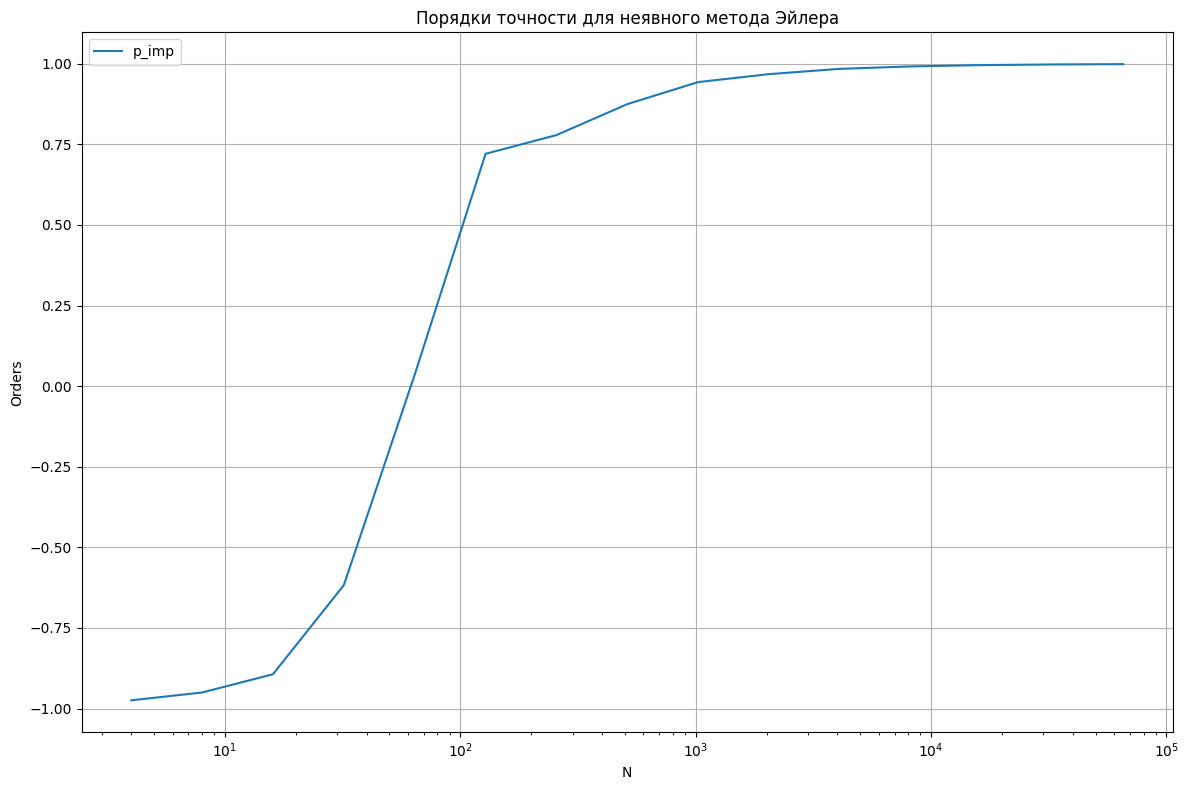

In [19]:
"""
Построим график изменения порядка
"""

plt.figure(figsize=(12,8))
plt.semilogx(N, p_imp, label="p_imp")
plt.title("Порядки точности для неявного метода Эйлера")
plt.xlabel("N")
plt.ylabel("Orders")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

Локальная погрешность метода = 2 $\Longrightarrow$ глобальная = 1. Вычисления соответствуют теории.

### Модифицированный метод Эйлера (метод предиктора-корректора)  

Метод реализуется с помощью системы, состоящей из **предиктора** и **корректора**.  

**Предиктор**: $$ \widetilde{y_{i+1}} = y_i + hf(x_i, y_i)$$  
Предиктор дает предварительное приближение в точке с помощью обычного метода Эйлера. 

**Корректор**: $$y_{i+1} = y_i + \frac{h}{2}(f(x_i, y_i) + f(x_i + h, \widetilde{y_{i+1}}))$$
Корректор уточняет шаг, усредняя наклон: в начале и в конце шага.  

Подставляем предиктор в корректор и получаем одношаговую формулу: $$y_{i+1} = y_i + \frac{h}{2}(f(x_i, y_i) + f(x_i + h, y_i + hf(x_i, y_i)))$$

In [20]:
def modified_euler(t, y, h, f):
    y_pred = y + h * f(t,y)
    
    y_next = y + h / 2 * (f(t, y) + f(t + h, y_pred))

    return y_next

In [21]:
errors_mod = []

for n in N:
    domain, h = grid(a, b, n)

    values_mod = [y0]
    values_analytic = [analytic_solution(y0, Lambda, domain[0], domain[0])]

    for t in range(1, len(domain)):
        values_mod.append(modified_euler(domain[t-1], values_mod[t-1], h, f))
        values_analytic.append(analytic_solution(y0, Lambda, domain[0], domain[t]))

    errors_mod.append(inaccuracy(values_analytic, values_mod))

p_mod = [np.nan] + [np.log2(errors_mod[i-1] / errors_mod[i]) for i in range(1, len(errors_mod))]

df_mod = pd.DataFrame({
    "N": N,
    "h": H,
    "eps_mod": errors_mod,
    "p_mod": p_mod
})

display(df_mod)

,N,h,eps_mod,p_mod
0,2,55.000000,3.190833e+07,NaN
1,4,27.500000,2.293033e+11,-12.811036
2,8,13.750000,3.001382e+16,-16.998010
3,16,6.875000,1.466637e+21,-15.576526
4,32,3.437500,2.947475e+18,8.958817
5,64,1.718750,8.685160e+00,58.235633
6,128,0.859375,1.296916e+00,2.743468
7,256,0.429688,2.347418e-01,2.465938
8,512,0.214844,4.997921e-02,2.231675
9,1024,0.107422,1.150955e-02,2.118497


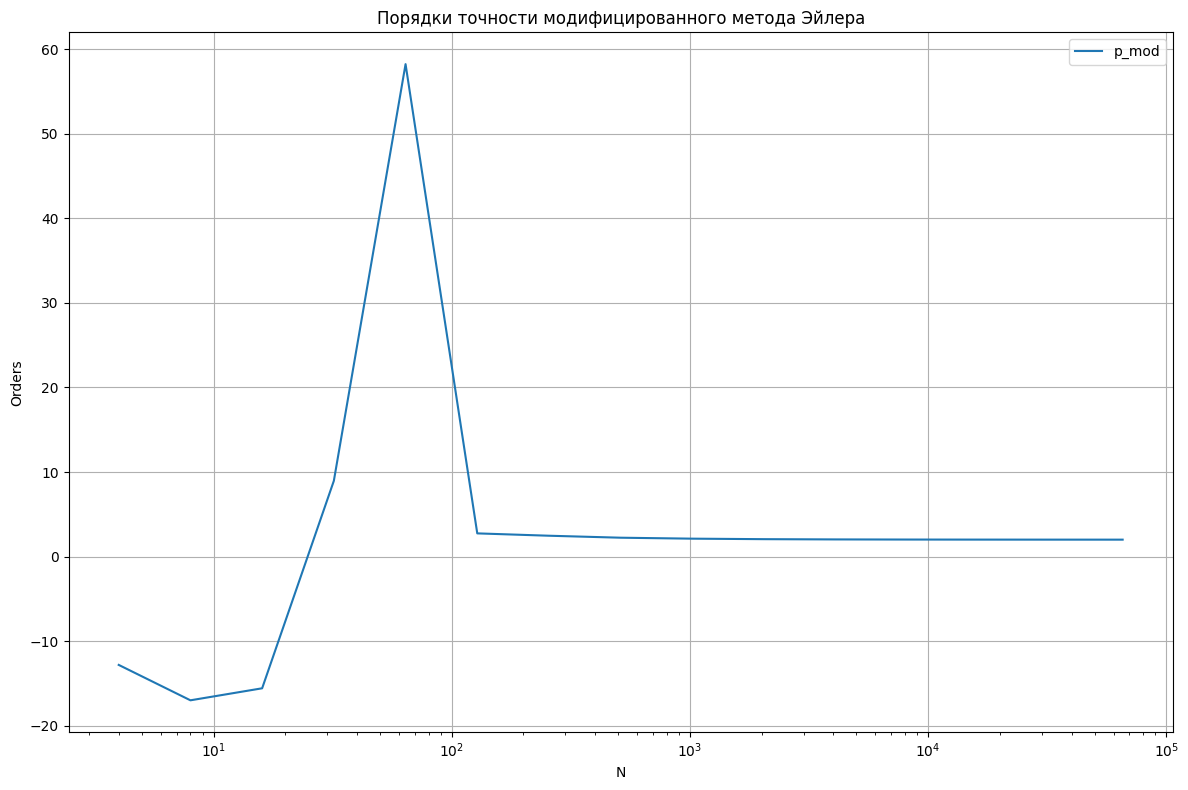

In [22]:
"""
Построим график изменения порядка
"""

plt.figure(figsize=(12,8))
plt.semilogx(N, p_mod, label="p_mod")
plt.title("Порядки точности модифицированного метода Эйлера")
plt.xlabel("N")
plt.ylabel("Orders")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

локальная погрешность метода = 3 $\Longrightarrow$ глобальная = 2

### 4 метод (метод центральных разностей).  
$$f(y_n) = \frac{y_{n+1} - y_{n-1}}{2h}$$
Для уравнения $y' = f(t,y)$ подставляем вместо $y'$: $f(t_n, y_n) = \frac{y_{n+1} - y_{n-1}}{2h}$, получаем:  
$$y_{n+1} = y_{n-1} + 2hf(t_n, y_n)$$

In [23]:
def central_difference_method(t, y_prev, y_current, h, f):
    return y_prev + 2*h*f(t, y_current)

In [24]:
errors_cd = []

for n in N:
    domain, h = grid(a, b, n)
    
    values_cd = [y0]

    values_cd.append(values_cd[0] + h * f(domain[0], values_cd[0]))

    values_analytic = [
        analytic_solution(y0, Lambda, domain[0], domain[0]),
        analytic_solution(y0, Lambda, domain[0], domain[1])
    ]

    for t in range(1, len(domain)-1):
        values_cd.append(
            central_difference_method(domain[t], values_cd[t-1], values_cd[t], h, f)
        )
        values_analytic.append(
            analytic_solution(y0, Lambda, domain[0], domain[t+1])
        )

    errors_cd.append(inaccuracy(values_analytic, values_cd))

p_cd = [np.nan] + [np.log2(errors_cd[i-1] / errors_cd[i]) for i in range(1, len(errors_cd))]

df_cd = pd.DataFrame({
    "N": N,
    "h": H,
    "eps_cd": errors_cd,
    "p_cd": p_cd
})

display(df_cd)

,N,h,eps_cd,p_cd
0,2,55.000000,8.911500e+04,NaN
1,4,27.500000,6.622318e+07,-9.537452
2,8,13.750000,2.299350e+12,-15.083530
3,16,6.875000,1.139919e+19,-22.241202
4,32,3.437500,6.466022e+27,-29.079372
5,64,1.718750,9.789775e+36,-30.495750
6,128,0.859375,3.366243e+43,-21.713360
7,256,0.429688,1.575094e+46,-8.870083
8,512,0.214844,4.323771e+46,-1.456852
9,1024,0.107422,2.058101e+46,1.070976


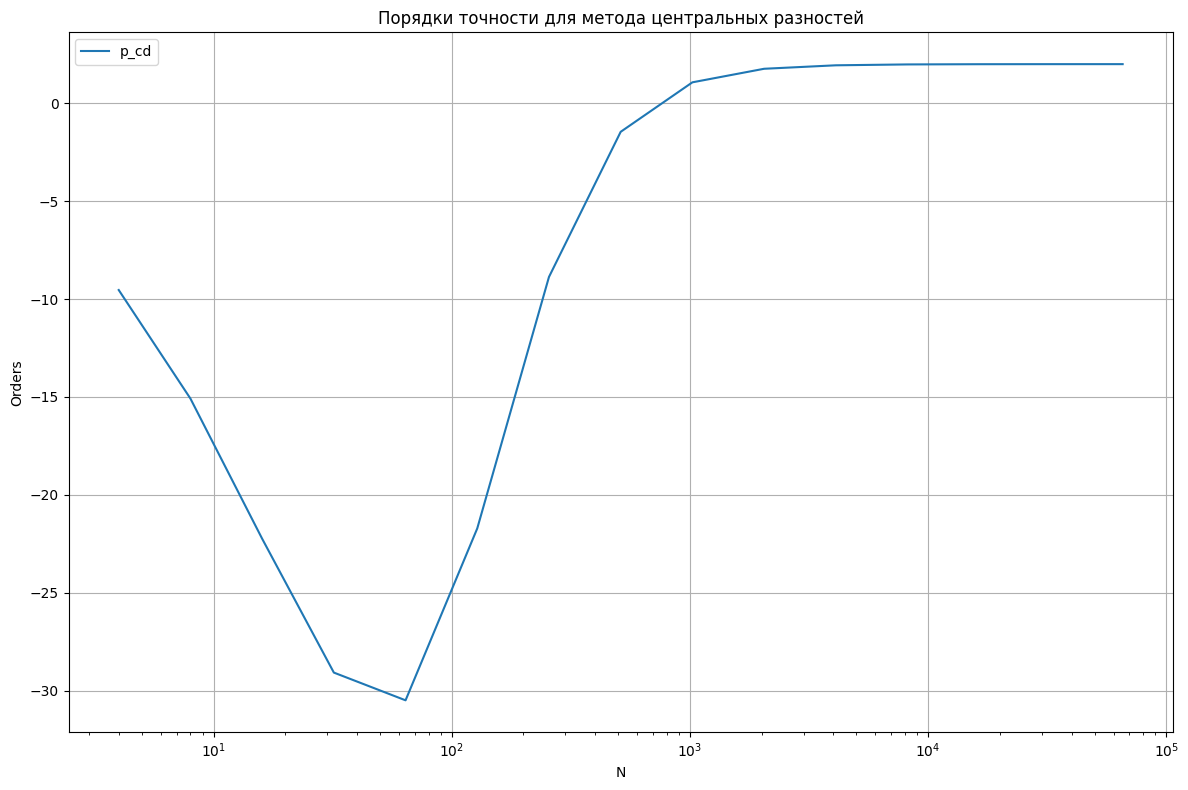

In [25]:
"""
Построим график изменения порядка
"""

plt.figure(figsize=(12,8))
plt.semilogx(N, p_cd, label="p_cd")
plt.title("Порядки точности для метода центральных разностей")
plt.xlabel("N")
plt.ylabel("Orders")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

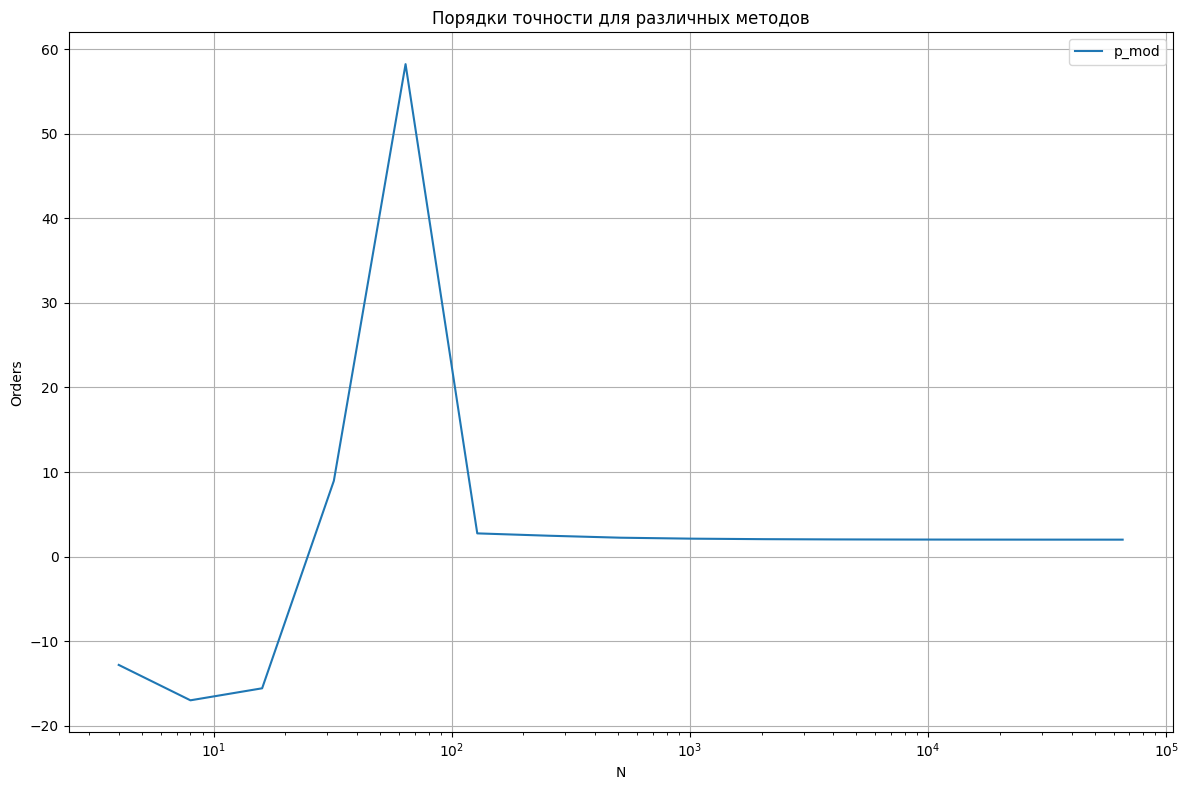

In [26]:
"""
Построим график изменения порядков всех методов
"""

plt.figure(figsize=(12,8))
#plt.semilogx(N, p_cd, label="p_cd")
plt.semilogx(N, p_mod, label="p_mod")
#plt.semilogx(N, p_imp, label="p_imp")
#plt.semilogx(N, p1, label="p1")
#plt.semilogx(N, p2, label="p2")
#plt.semilogx(N, p3, label="p3")
plt.title("Порядки точности для различных методов")
plt.xlabel("N")
plt.ylabel("Orders")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [27]:
def build_error_table(methods, N, a, b, y0, f, Lambda):
    def one_step_error(method, n):
        domain, h = grid(a, b, n)

        values = [y0]
        values_analytic = [analytic_solution(y0, Lambda, domain[0], domain[0])]

        for t in range(1, len(domain)):
            values.append(method(domain[t-1], values[t-1], h, f))
            values_analytic.append(
                analytic_solution(y0, Lambda, domain[0], domain[t])
            )

        err = inaccuracy(values_analytic, values)
        return h, err

    def two_step_error(method, n):
        domain, h = grid(a, b, n)

        values = [y0]
        values.append(y0 + h * f(domain[0], y0))  

        values_analytic = [
            analytic_solution(y0, Lambda, domain[0], domain[0]),
            analytic_solution(y0, Lambda, domain[0], domain[1])
        ]

        for t in range(1, len(domain) - 1):
            values.append(method(domain[t], values[t-1], values[t], h, f))
            values_analytic.append(
                analytic_solution(y0, Lambda, domain[0], domain[t+1])
            )

        err = inaccuracy(values_analytic, values)
        return h, err

    data = {
        "N": N,
        "h": []
    }

    for method_name, method_info in methods.items():
        method_func = method_info["func"]
        method_type = method_info["type"]

        errors = []
        hs = []

        for n in N:
            if method_type == "one-step":
                h, err = one_step_error(method_func, n)
            elif method_type == "two-step":
                h, err = two_step_error(method_func, n)
            else:
                raise ValueError(f"Unknown method type: {method_type}")

            hs.append(h)
            errors.append(err)

        orders = [np.nan]

        for i in range(1, len(errors)):
            e_prev = errors[i-1]
            e_curr = errors[i]

            if e_prev == 0 or e_curr == 0 or not np.isfinite(e_prev) or not np.isfinite(e_curr):
                orders.append(np.nan)
            else:
                orders.append(np.log2(e_prev / e_curr))

        if len(data["h"]) == 0:
            data["h"] = hs

        data[f"eps_{method_name}"] = errors
        data[f"p_{method_name}"] = orders

    return pd.DataFrame(data)

In [28]:
methods = {
    "ps1": {"func": power_series_method_1, "type": "one-step"},
    "ps2": {"func": power_series_method_2, "type": "one-step"},
    "ps3": {"func": power_series_method_3, "type": "one-step"},
    "imp": {"func": implicit_method, "type": "one-step"},
    "mod": {"func": modified_euler, "type": "one-step"},
    "cd": {"func": central_difference_method, "type": "two-step"},
}

df_all = build_error_table(methods, N, a, b, y0, f, Lambda)
display(df_all)

,N,h,eps_ps1,p_ps1,eps_ps2,p_ps2,eps_ps3,p_ps3,eps_imp,p_imp,eps_mod,p_mod,eps_cd,p_cd
0,2,55.000000,4.374000e+04,NaN,3.190833e+07,NaN,1.035222e+10,NaN,0.267857,NaN,3.190833e+07,NaN,8.911500e+04,NaN
1,4,27.500000,7.397326e+06,-7.401907,2.293033e+11,-12.811036,1.411420e+15,-17.056848,0.526316,-0.974465,2.293033e+11,-12.811036,6.622318e+07,-9.537452
2,8,13.750000,1.047545e+10,-10.467721,3.001382e+16,-16.998010,3.494340e+21,-21.239441,1.016933,-0.950224,3.001382e+16,-16.998010,2.299350e+12,-15.083530
3,16,6.875000,3.021462e+13,-11.494019,1.466637e+21,-15.576526,1.425116e+26,-15.315699,1.889262,-0.893598,1.466637e+21,-15.576526,1.139919e+19,-22.241202
4,32,3.437500,3.616756e+13,-0.259449,2.947475e+18,8.958817,5.818368e+17,27.867817,2.898107,-0.617288,2.947475e+18,8.958817,6.466022e+27,-29.079372
5,64,1.718750,1.347060e+01,41.288019,8.685160e+00,58.235633,4.008245e+00,57.010421,2.827890,0.035385,8.685160e+00,58.235633,9.789775e+36,-30.495750
6,128,0.859375,4.242025e+00,1.666989,1.296916e+00,2.743468,2.897598e-01,3.790041,1.715827,0.720821,1.296916e+00,2.743468,3.366243e+43,-21.713360
7,256,0.429688,1.472554e+00,1.526432,2.347418e-01,2.465938,2.547973e-02,3.507436,1.000026,0.778867,2.347418e-01,2.465938,1.575094e+46,-8.870083
8,512,0.214844,6.508645e-01,1.177892,4.997921e-02,2.231675,2.701658e-03,3.237433,0.545306,0.874898,4.997921e-02,2.231675,4.323771e+46,-1.456852
9,1024,0.107422,3.105324e-01,1.067613,1.150955e-02,2.118497,3.104538e-04,3.121395,0.283581,0.943305,1.150955e-02,2.118497,2.058101e+46,1.070976


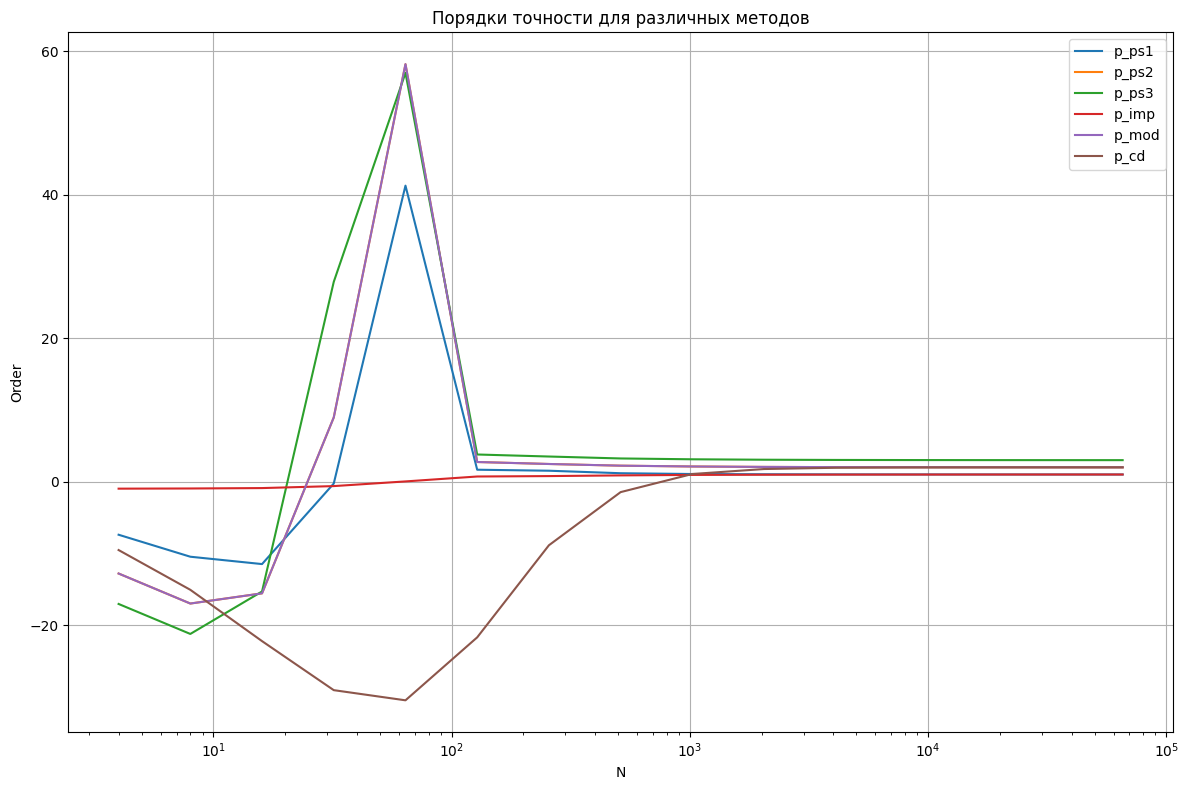

In [29]:
plt.figure(figsize=(12,8))

for col in df_all.columns:
    if col.startswith("p_"):
        plt.semilogx(df_all["N"], df_all[col], label=col)

plt.title("Порядки точности для различных методов")
plt.xlabel("N")
plt.ylabel("Order")

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

### Часть 2: разные $\lambda$

In [30]:
lambdas = [-i for i in range(1, 16)]

Lambda = -1



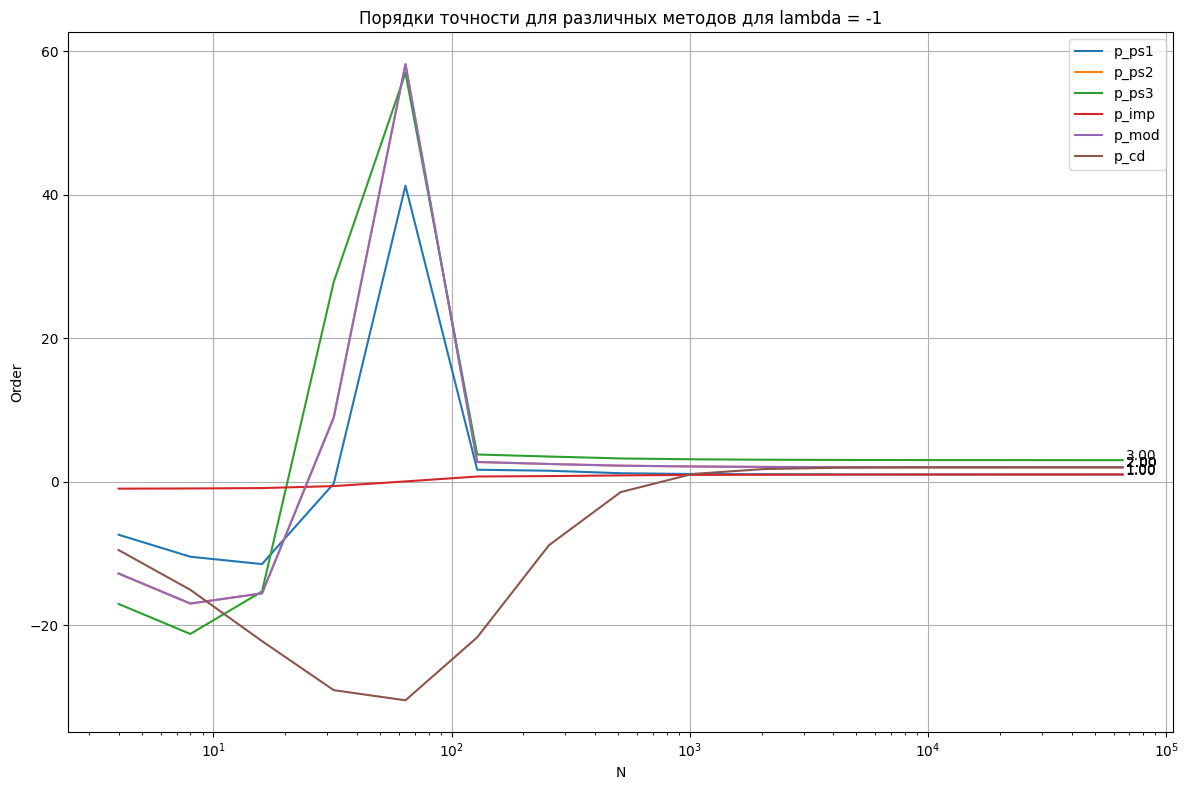

Lambda = -2



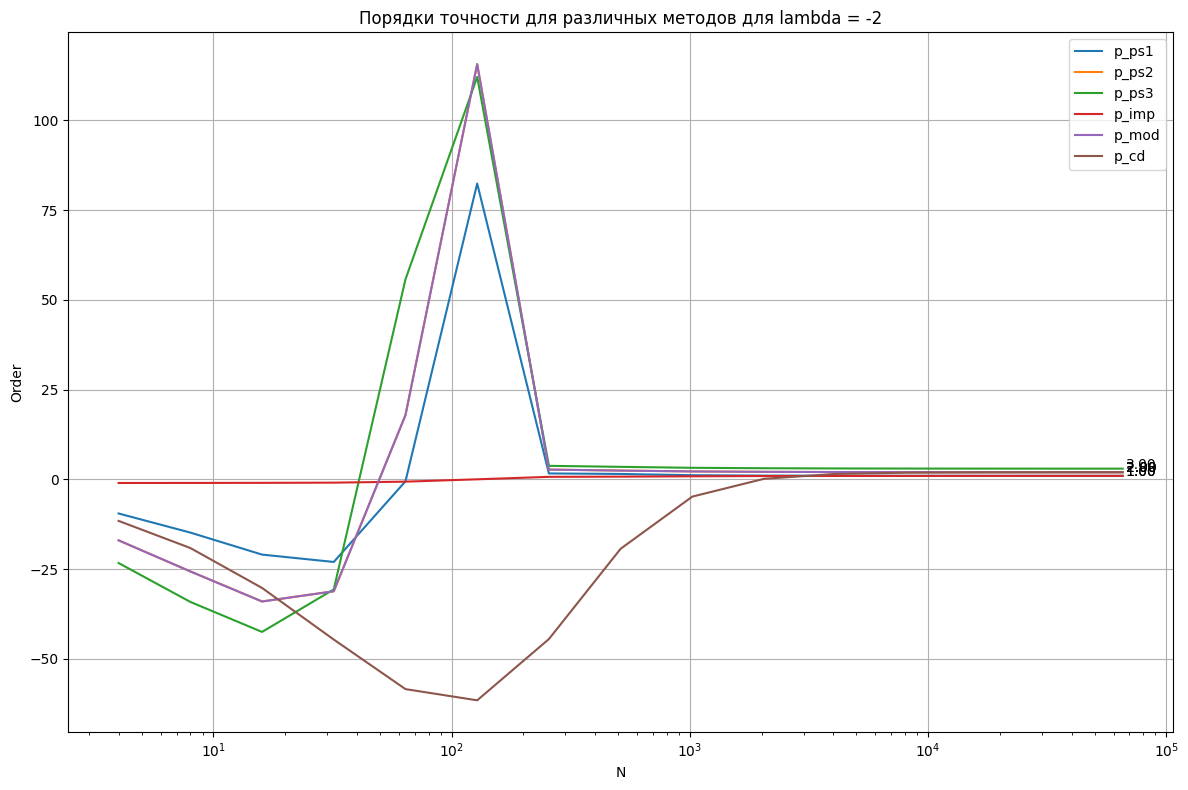

Lambda = -3



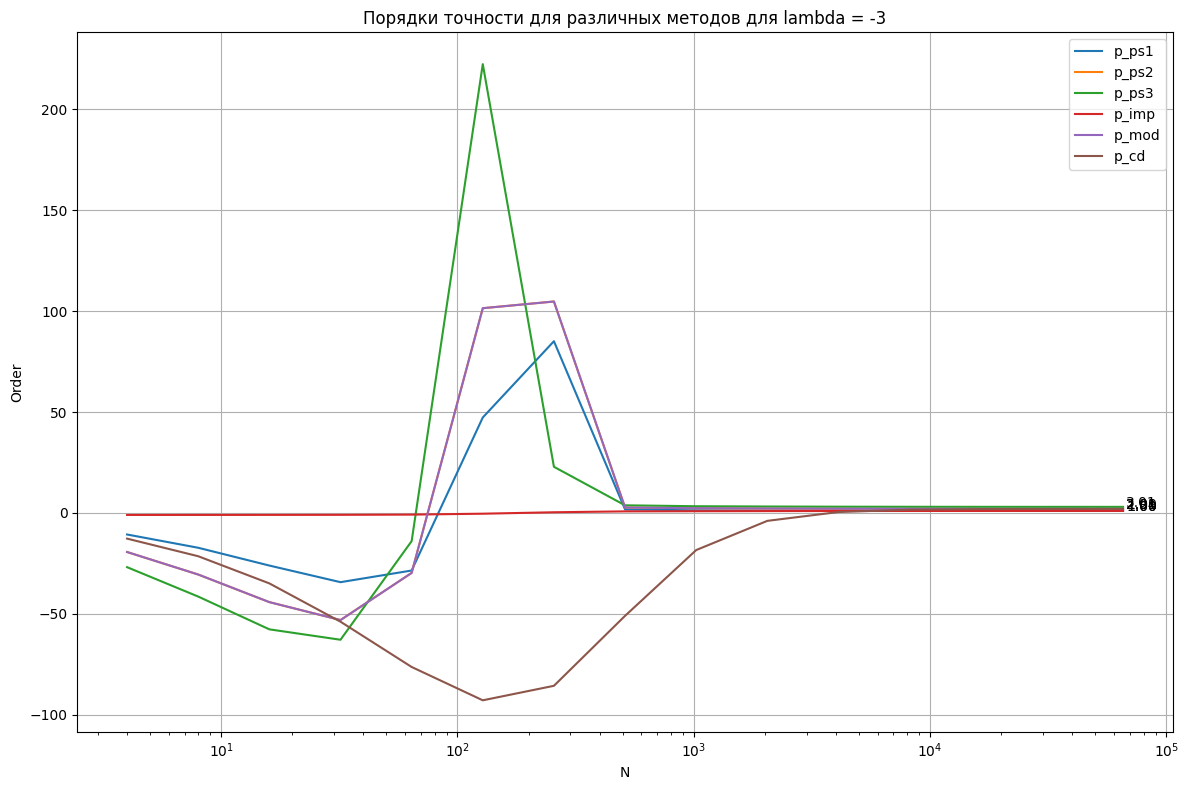

Lambda = -4



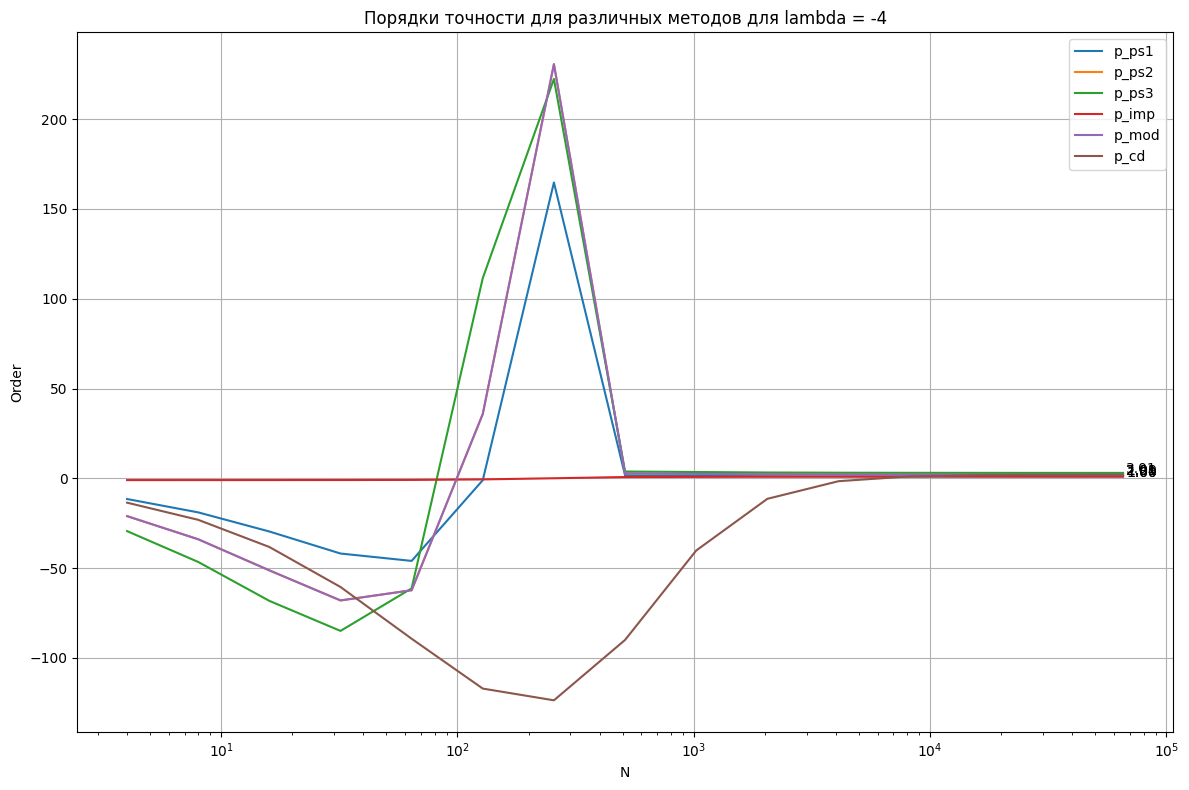

Lambda = -5



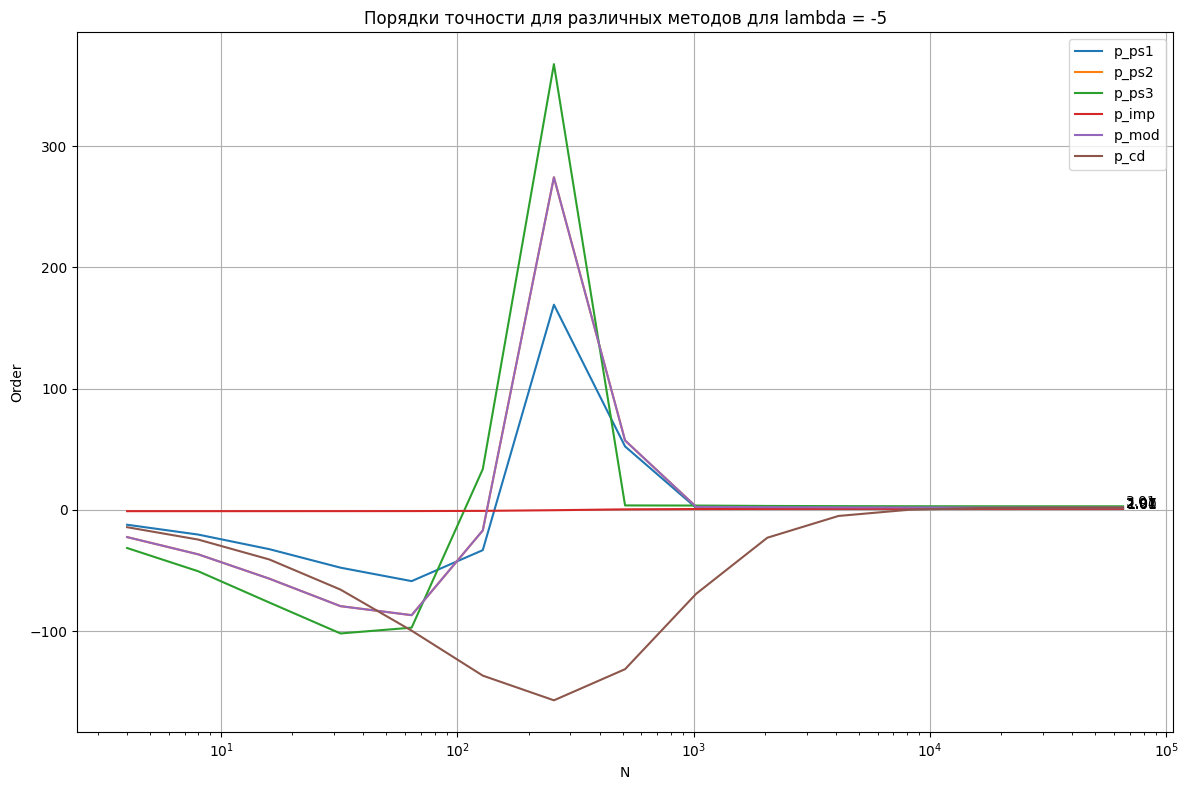

Lambda = -6



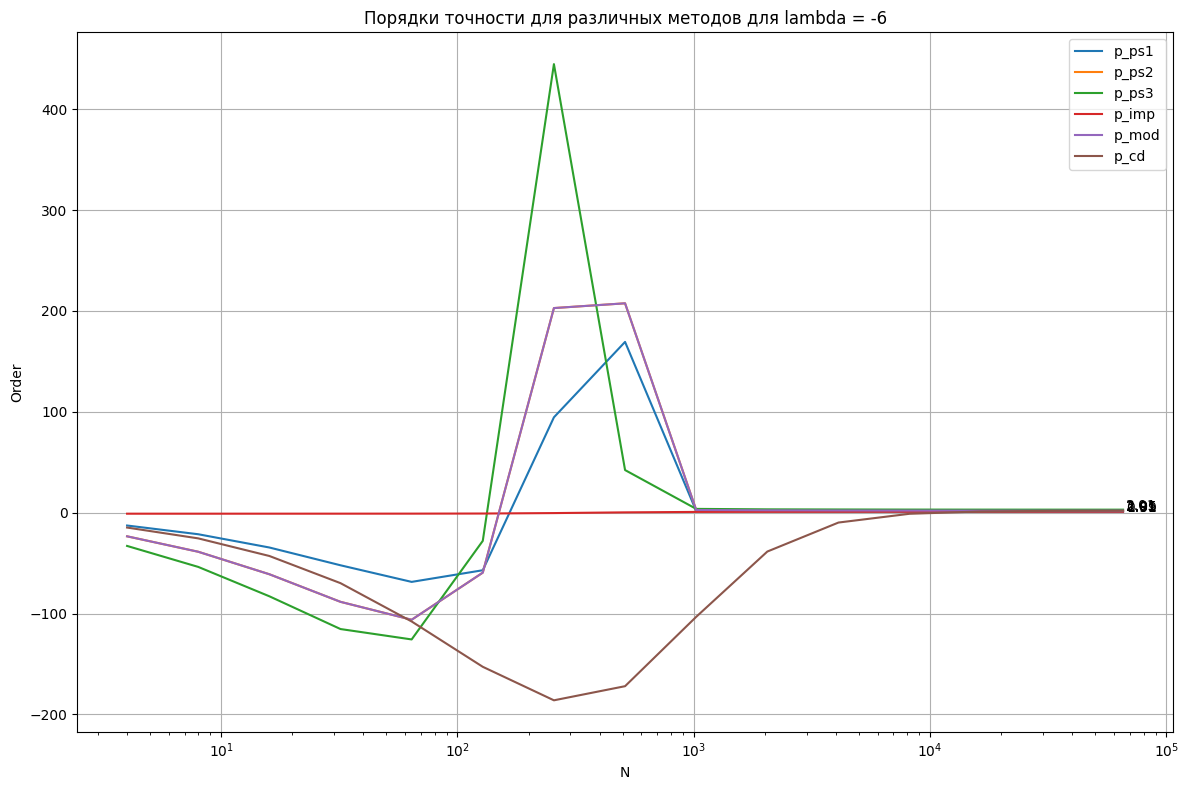

Lambda = -7



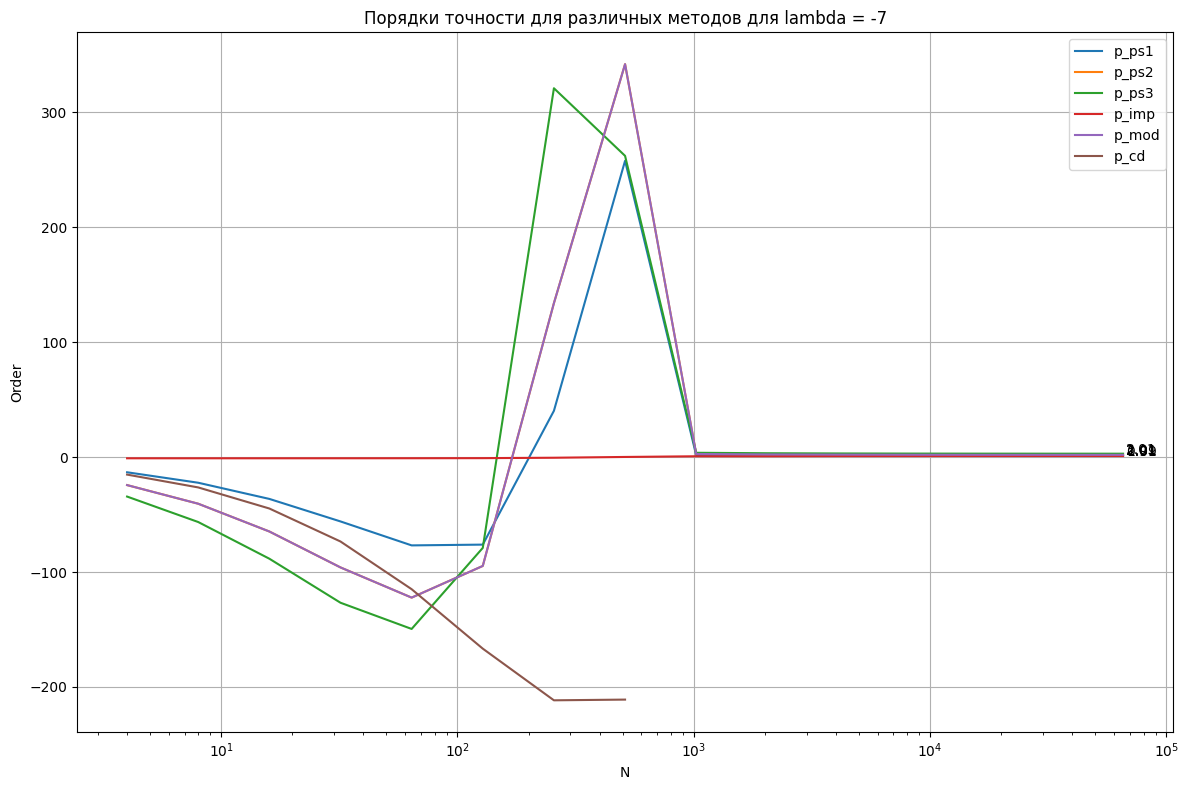

Lambda = -8



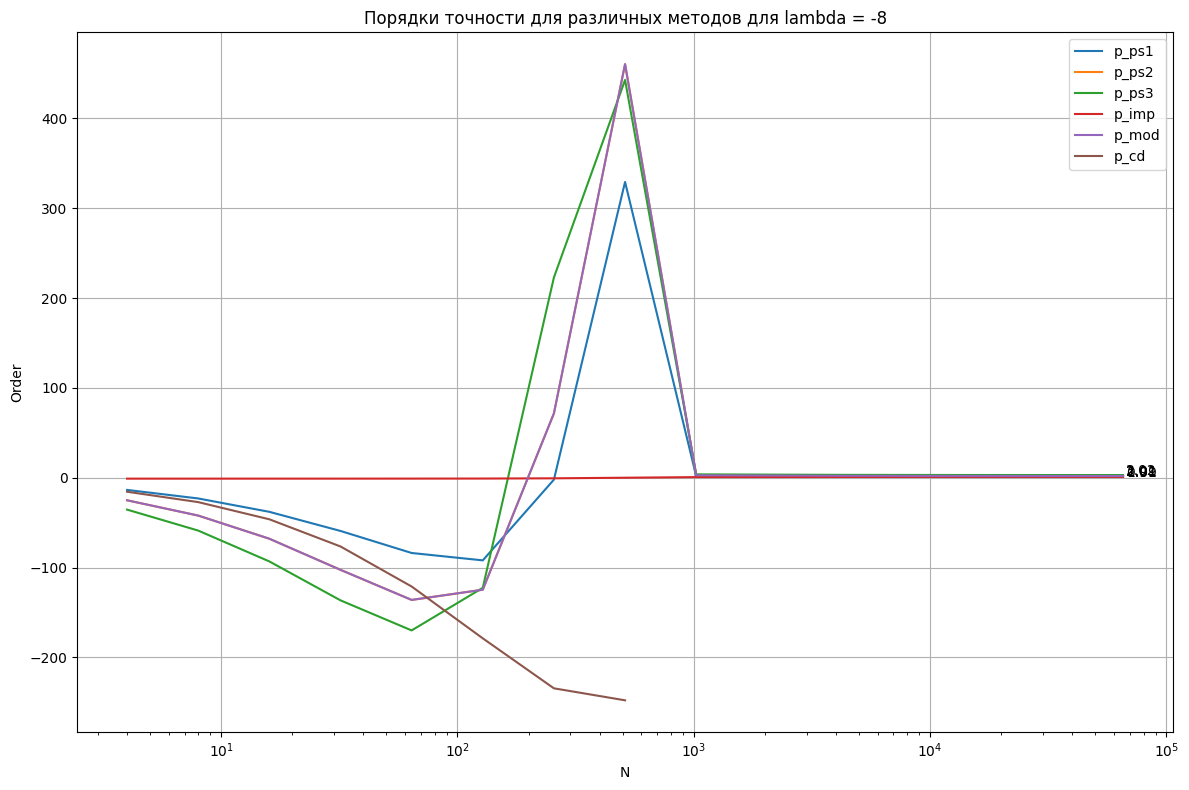

Lambda = -9



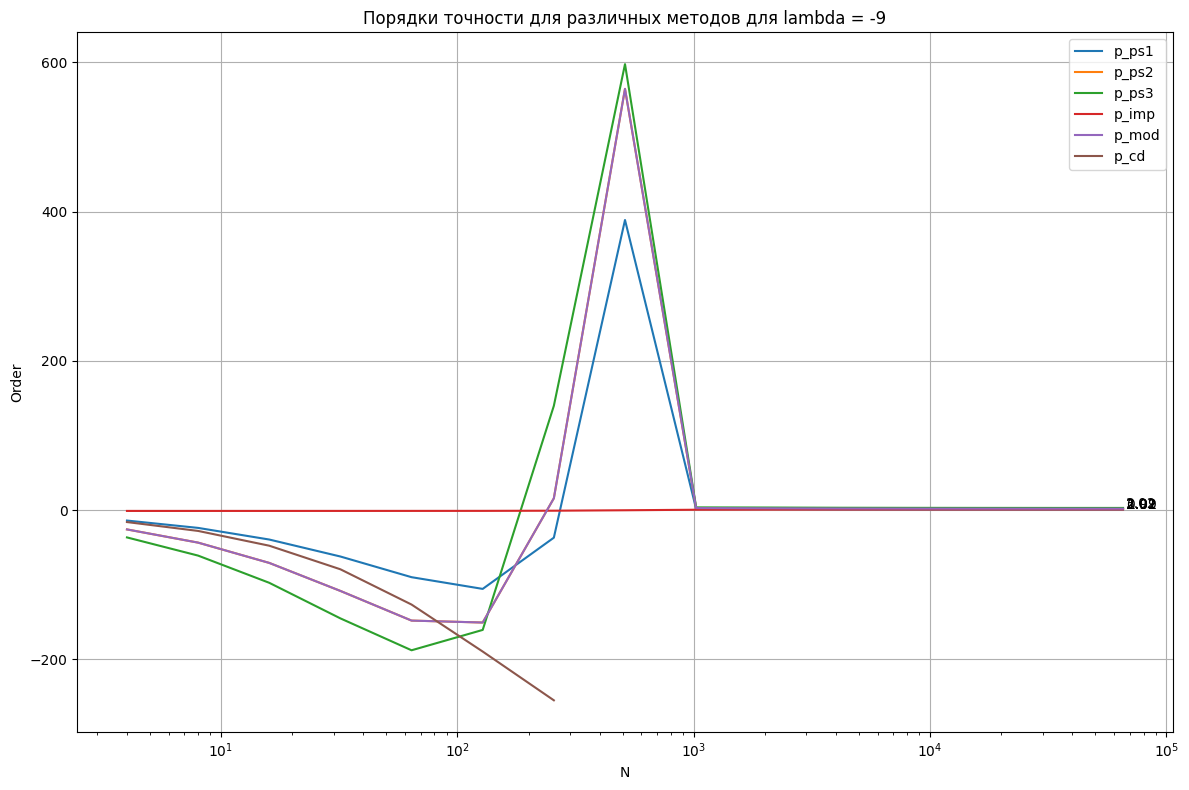

Lambda = -10



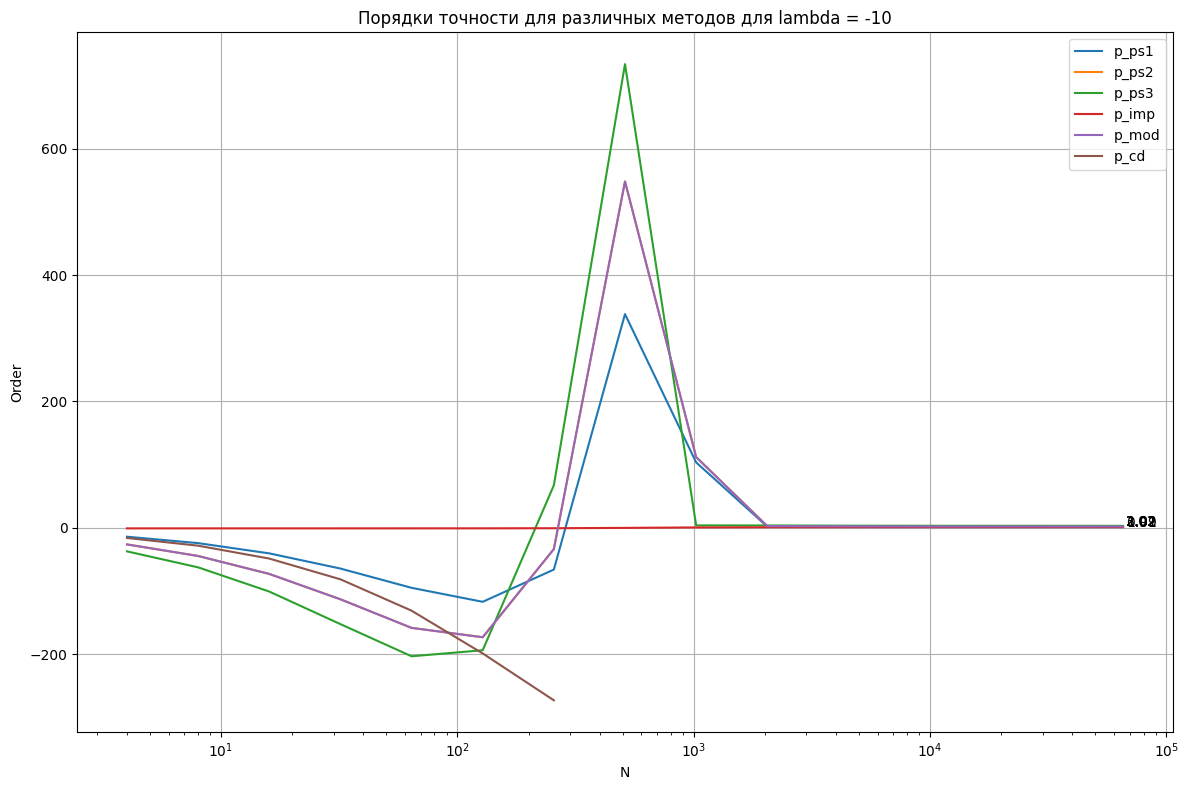

Lambda = -11



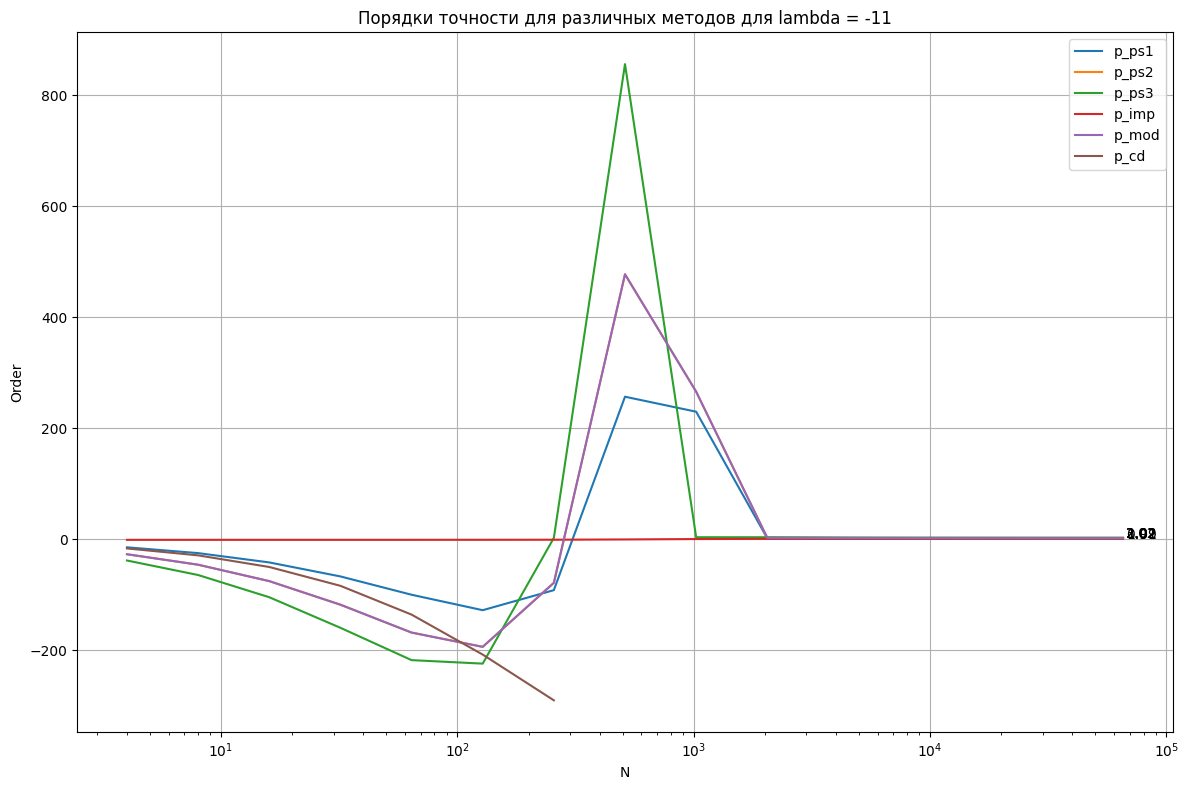

Lambda = -12



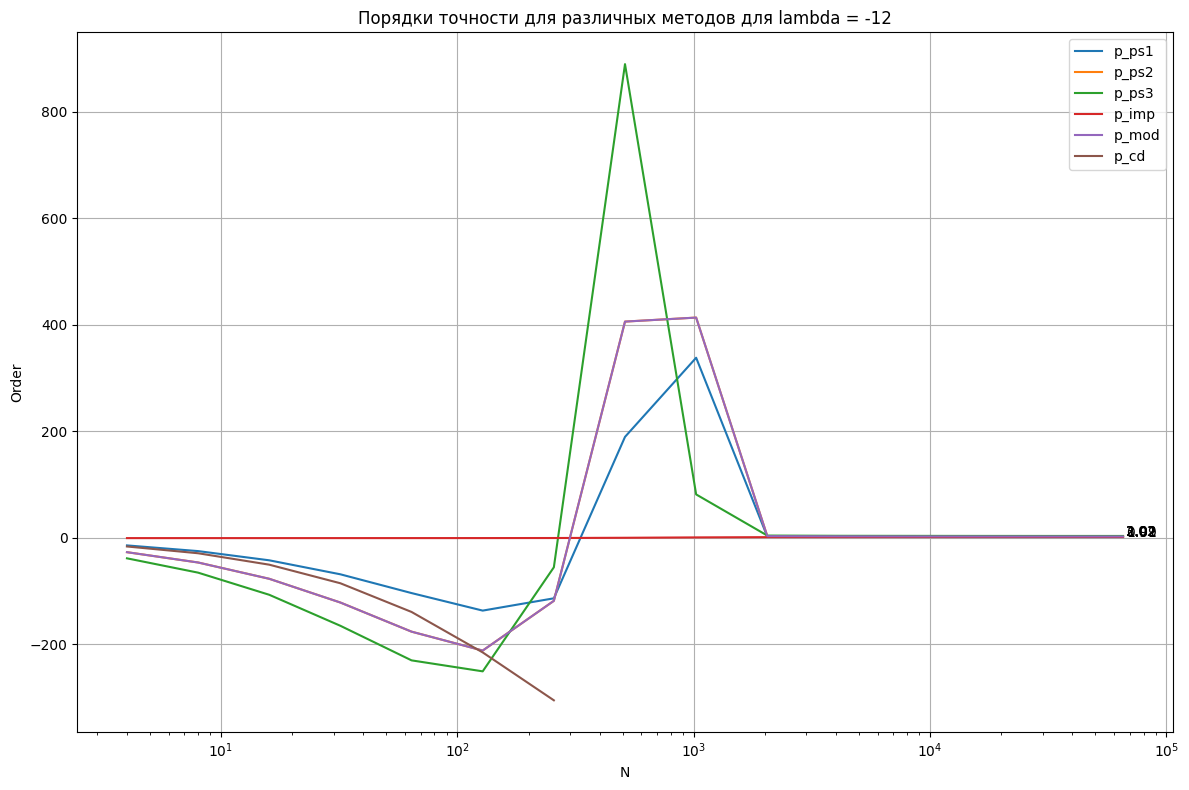

Lambda = -13



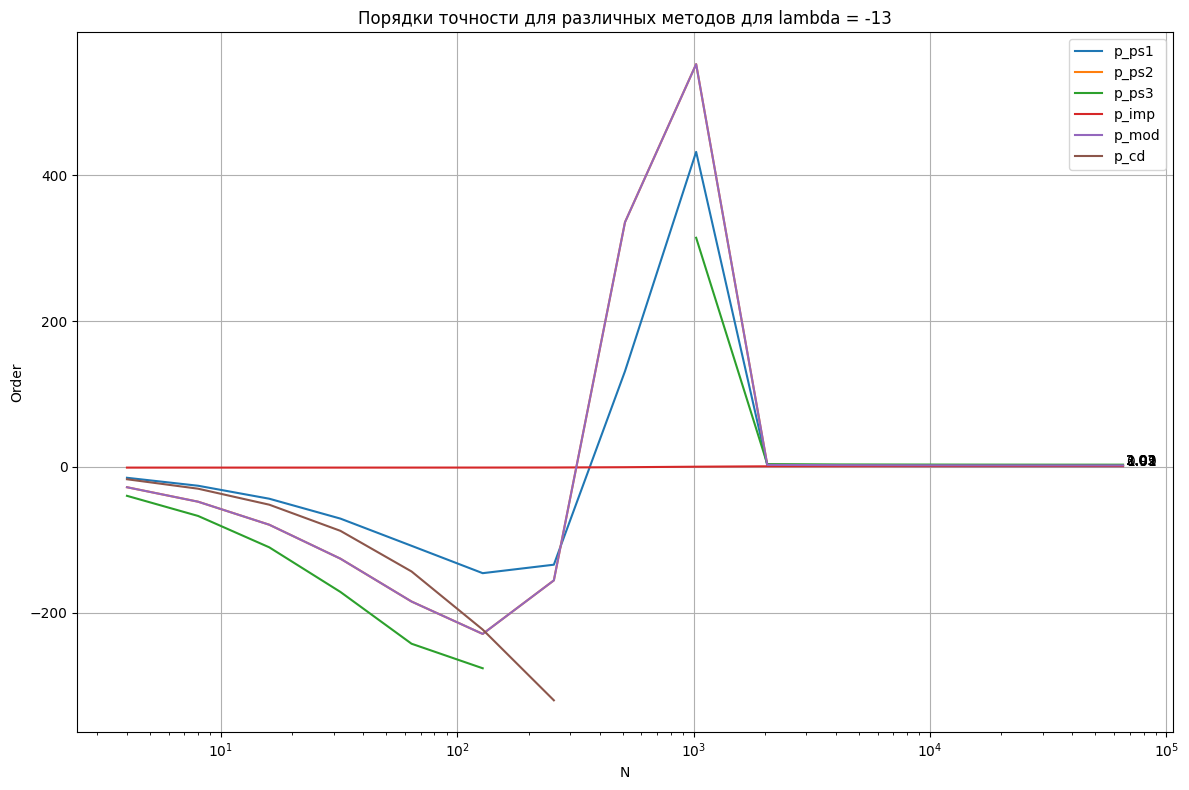

Lambda = -14



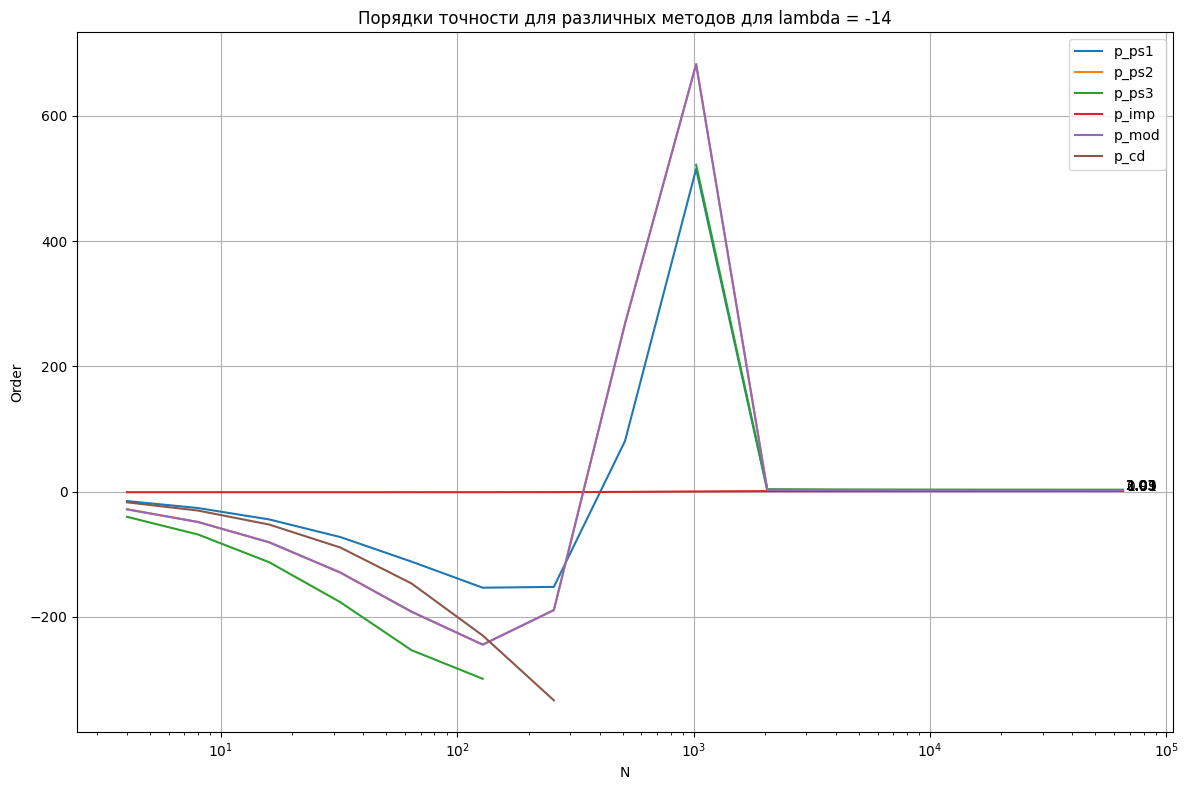

Lambda = -15



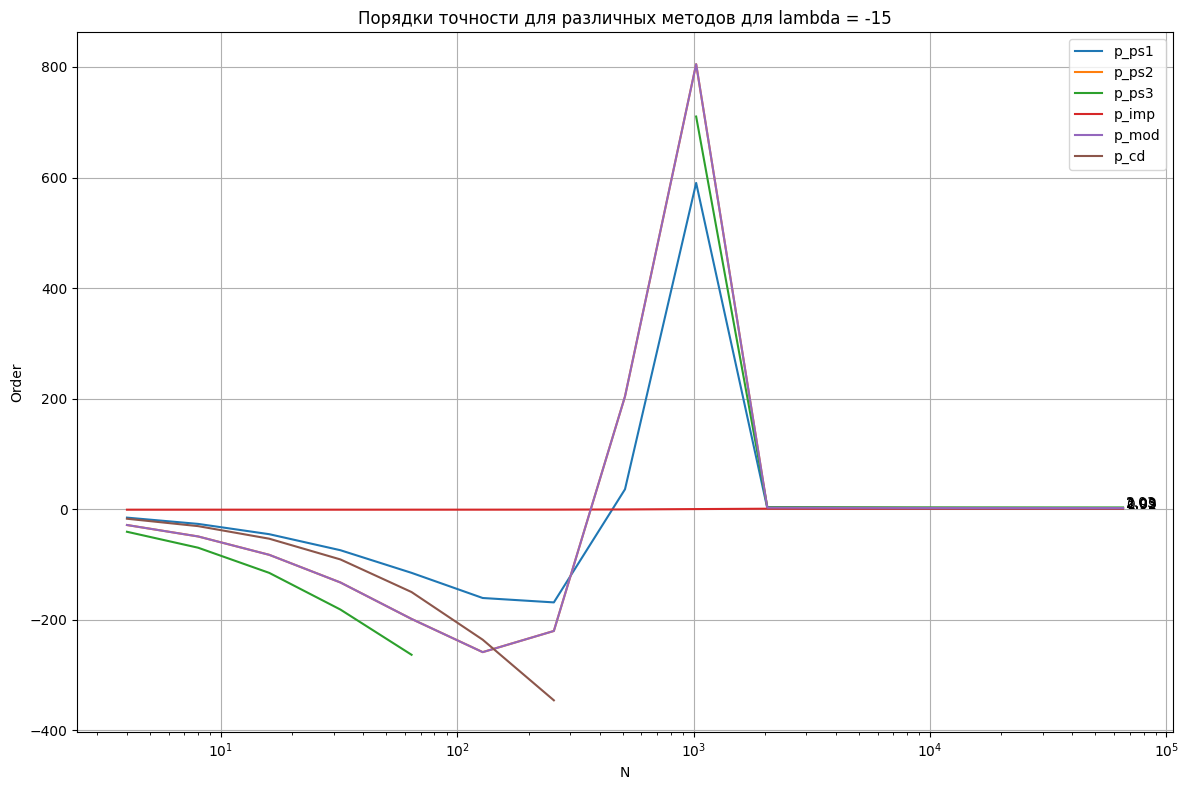

In [31]:
for l in lambdas:
    Lambda = l
    f = lambda t, y: Lambda * y
    df_all = build_error_table(methods, N, a, b, y0, f, Lambda)
    print(f"Lambda = {l}\n")

    plt.figure(figsize=(12,8))

    for col in df_all.columns:
        if col.startswith("p_"):
            plt.semilogx(df_all["N"], df_all[col], label=col)

            x = df_all["N"].iloc[-1]
            y = df_all[col].iloc[-1]

            if np.isfinite(y):
                plt.text(x * 1.03, y, f"{y:.2f}")

    plt.title(f"Порядки точности для различных методов для lambda = {l}")
    plt.xlabel("N")
    plt.ylabel("Order")

    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()